### 🚀 Asteroid Diameter Prediction – Simple Model

This notebook focuses on preparing data and building simple models to predict asteroid diameters using various regression techniques. We use a cleaned dataset and apply exploratory data analysis (EDA), outlier handling, and log transformation before training.
- The modeling is done only with rows where 'diameter' is present. 'Albedo' is dropped.
- This model can be used to predict 'diameter' as 'albedo' is not used.

---

#### 📦 Imports
We import necessary packages for regression modeling, visualization, preprocessing, and evaluation.

In [2]:
import pandas as pd
import numpy as np

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Explainability
import shap

# Model evaluation & tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#### 📑 Load Cleaned Asteroid Dataset
We load the preprocessed dataset and select rows where `diameter` values are available, which is important for this regression.

In [3]:
asteroid = pd.read_csv('data/asteroid_cleaned.csv', index_col="full_name")

# Extracting rows where diameter is present
ast_dia = asteroid[asteroid['diameter'].notna()]

# Drop "albedo" feature
ast_dia = ast_dia.drop(columns = ['albedo'])

### 🧹 Outlier Removal and Log Transformation

We apply a log transformation to stabilize variance and reduce skewness. Extreme outliers (above the 99.75th percentile) are filtered out to prevent bias in training.

We then split the dataset into training and testing sets.

In [4]:
# Apply log transformation
y_log = np.log1p(ast_dia['diameter'])

# Remove top 0.25% outliers
upper_bound = np.percentile(y_log, 99.75)
ast_dia_filtered = ast_dia[y_log <= upper_bound]

# Features and target
X_filtered = ast_dia_filtered.drop('diameter', axis=1)
y_filtered = np.log1p(ast_dia_filtered['diameter'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

#### 📊 Visualizing Diameter Distribution after outlier removal
We inspect the distribution of the log of target variable `diameter` using histograms.

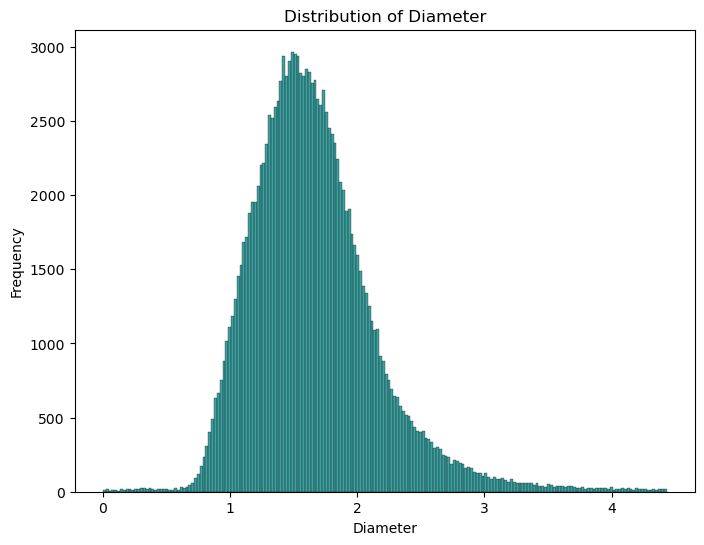

In [5]:
plt.figure(figsize=(8, 6))
sns.histplot(np.log1p(ast_dia_filtered['diameter']), color='teal')
plt.title('Distribution of Diameter')
plt.xlabel('Diameter')
plt.ylabel('Frequency')
plt.show()

### 🔍 Regression

We start with a basic linear regression model as a baseline. Then continue on to Random Forest, XGBoost, LightBGM and Catboost. After training, we evaluate performance using both log-transformed and original scale metrics.

In [6]:
# 📈 LINEAR REGRESSION
# Training a simple linear regression model to establish a baseline.

# Initialize and train the model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = lin_model.predict(X_test)
y_train_pred = lin_model.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0542, R² Score: 0.7786
Test  Mean Squared Error: 0.0552, R² Score: 0.7807
Original Scale - Test MSE: 8.5767, R²: 0.6991


In [7]:
# Random forest regression
# Using Random Forest to capture nonlinear relationships and interactions.

# # Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0047, R² Score: 0.9808
Test  Mean Squared Error: 0.0336, R² Score: 0.8666
Original Scale - Test MSE: 3.1878, R²: 0.8882


In [8]:
# XGBOOST REGRESSION
# Applying XGBoost for powerful gradient boosting with regularization.

# Initialize and train XGBRegressor
xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
xgb_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = xgb_reg.predict(X_test)
y_train_pred = xgb_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0274, R² Score: 0.8881
Test  Mean Squared Error: 0.0340, R² Score: 0.8651
Original Scale - Test MSE: 3.3062, R²: 0.8840


In [9]:
# LightBGM REGRESSION
# Training LightGBM for efficient gradient boosting with fast training.

# Initialize and train LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(objective='regression', random_state=42)
lgb_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = lgb_reg.predict(X_test)
y_train_pred = lgb_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

c:\Users\aj20j\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\aj20j\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4439
[LightGBM] [Info] Number of data points in the train set: 109484, number of used features: 30
[LightGBM] [Info] Start training from score 1.659920
Train Mean Squared Error: 0.0331, R² Score: 0.8647
Test  Mean Squared Error: 0.0351, R² Score: 0.8608
Original Scale - Test MSE: 3.1132, R²: 0.8908


In [10]:
# Catboost regression

# Initialize and train CatBoost Regressor
cat_reg = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)
cat_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = cat_reg.predict(X_test)
y_train_pred = cat_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.4842527	total: 171ms	remaining: 2m 50s
200:	learn: 0.2008181	total: 1.43s	remaining: 5.69s
400:	learn: 0.1932402	total: 2.43s	remaining: 3.63s
600:	learn: 0.1885249	total: 3.41s	remaining: 2.27s
800:	learn: 0.1851582	total: 4.41s	remaining: 1.09s
999:	learn: 0.1827810	total: 5.39s	remaining: 0us
Train MSE: 0.0334, R²: 0.8636
Test  MSE: 0.0346, R²: 0.8626
Original Scale - Test MSE: 3.0271, R²: 0.8938


In [ ]:
# Define parameter grid for RandomizedSearchCV to tune CatBoost hyperparameters
params = {
    'depth': [6, 7, 8, 9],
    'learning_rate': [0.01, 0.05],
    'iterations': [2000],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
}

# Initialize CatBoostRegressor with silent mode to suppress output
model = CatBoostRegressor(silent=True)

# Perform Randomized Search CV with 20 iterations, 3-fold cross-validation, optimizing for R²
grid = RandomizedSearchCV(model, param_distributions=params, n_iter=20, cv=3, scoring='r2', verbose=1, random_state=42)

# Fit grid search on training data
grid.fit(X_train, y_train)

# Print best hyperparameters found by RandomizedSearchCV
print("Best params:", grid.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 2000, 'depth': 9}


In [11]:
# Catboost regression
# Utilizing CatBoost for handling categorical features and boosting accuracy.

# Initialize and train CatBoost Regressor
cat_reg_f = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=9,
    loss_function='RMSE',
    l2_leaf_reg=5,
    random_seed=42,
    verbose=500
)
cat_reg_f.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = cat_reg_f.predict(X_test)
y_train_pred = cat_reg_f.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.4763190	total: 19.7ms	remaining: 39.5s
500:	learn: 0.1741717	total: 5.96s	remaining: 17.8s
1000:	learn: 0.1627452	total: 11.7s	remaining: 11.7s
1500:	learn: 0.1541136	total: 18s	remaining: 5.98s
1999:	learn: 0.1468885	total: 24.4s	remaining: 0us
Train MSE: 0.0216, R²: 0.9119
Test  MSE: 0.0314, R²: 0.8754
Original Scale - Test MSE: 2.9420, R²: 0.8968


In [12]:
# --- Cross-validation to check overfitting ---

# Compute R² scores for 5-fold cross-validation on filtered data
scores = cross_val_score(cat_reg_f, X_filtered, y_filtered, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Mean R²:", scores.mean())

0:	learn: 0.3843076	total: 17.3ms	remaining: 34.6s
500:	learn: 0.1638926	total: 6.25s	remaining: 18.7s
1000:	learn: 0.1525751	total: 12.9s	remaining: 12.9s
1500:	learn: 0.1440024	total: 19.3s	remaining: 6.43s
1999:	learn: 0.1365943	total: 25.7s	remaining: 0us
0:	learn: 0.4902479	total: 21.3ms	remaining: 42.6s
500:	learn: 0.1689826	total: 6.67s	remaining: 19.9s
1000:	learn: 0.1572607	total: 13s	remaining: 13s
1500:	learn: 0.1481985	total: 19.4s	remaining: 6.44s
1999:	learn: 0.1407664	total: 25.7s	remaining: 0us
0:	learn: 0.4995461	total: 18.2ms	remaining: 36.4s
500:	learn: 0.1736955	total: 6.66s	remaining: 19.9s
1000:	learn: 0.1622897	total: 13.1s	remaining: 13.1s
1500:	learn: 0.1533042	total: 19.4s	remaining: 6.46s
1999:	learn: 0.1456071	total: 25.9s	remaining: 0us
0:	learn: 0.5026806	total: 20.6ms	remaining: 41.3s
500:	learn: 0.1804331	total: 6.88s	remaining: 20.6s
1000:	learn: 0.1684515	total: 13.5s	remaining: 13.5s
1500:	learn: 0.1594784	total: 20s	remaining: 6.66s
1999:	learn: 0.15

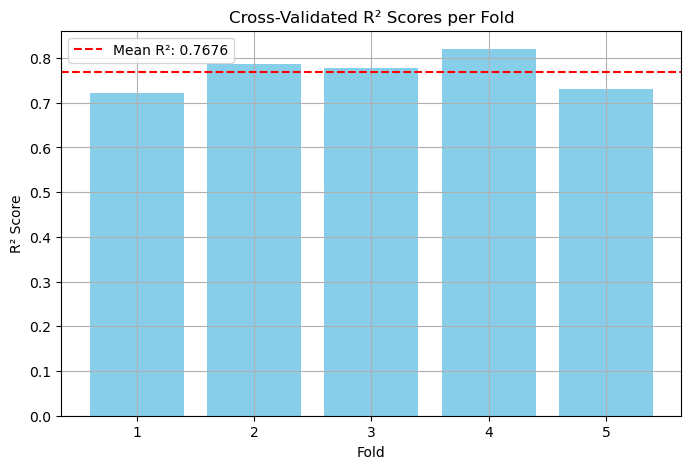

In [13]:
# CV scores
r2_scores = [0.7227603, 0.78677408, 0.77721992, 0.82000425, 0.73135606]

# Plot R² scores for each fold to visually inspect model consistency
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(r2_scores) + 1), r2_scores, color='skyblue')
plt.axhline(np.mean(r2_scores), color='red', linestyle='--', label=f'Mean R²: {np.mean(r2_scores):.4f}')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Cross-Validated R² Scores per Fold')
plt.legend()
plt.grid(True)
plt.show()

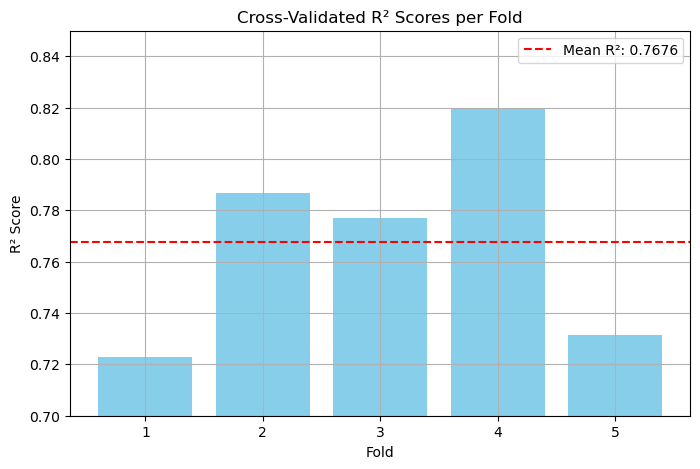

In [14]:
# Your CV scores
r2_scores = [0.7227603, 0.78677408, 0.77721992, 0.82000425, 0.73135606]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(r2_scores) + 1), r2_scores, color='skyblue')
plt.axhline(np.mean(r2_scores), color='red', linestyle='--', label=f'Mean R²: {np.mean(r2_scores):.4f}')
plt.ylim(0.7, 0.85)
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Cross-Validated R² Scores per Fold')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# --- Feature importance from CatBoost ---

# Get feature importance with readable format
cat_reg_f.get_feature_importance(prettified=True)

,Feature Id,Importances
0,H,41.268102
1,a,11.514194
2,n,10.848755
3,i,7.066069
4,tp,3.592983
5,e,3.564921
6,ma,3.353910
7,moid,2.594687
8,om,2.097982
9,n_obs_used,2.080315


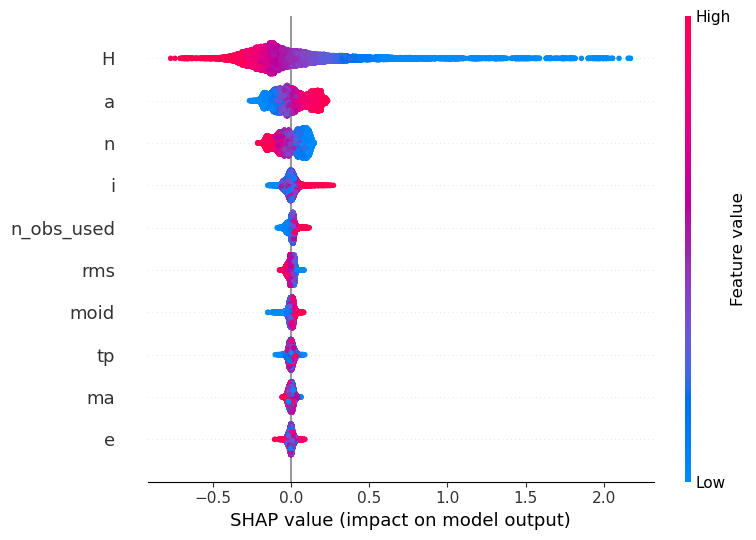

In [16]:
# --- SHAP analysis for model explainability ---

# Initialize SHAP explainer for the trained CatBoost model
explainer = shap.TreeExplainer(cat_reg_f)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Plot summary of SHAP values showing top 10 features impacting predictions
shap.summary_plot(shap_values, X_test, max_display=10)

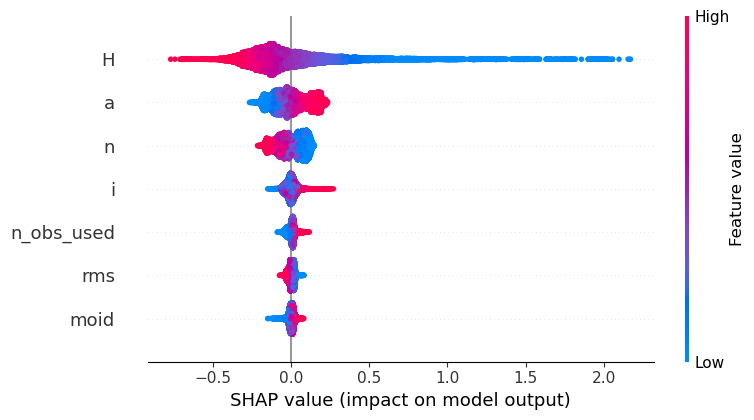

In [17]:
# --- SHAP analysis for model explainability ---

# Initialize SHAP explainer for the trained CatBoost model
explainer = shap.TreeExplainer(cat_reg_f)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Plot summary of SHAP values showing top 7 features impacting predictions
shap.summary_plot(shap_values, X_test, max_display=7)

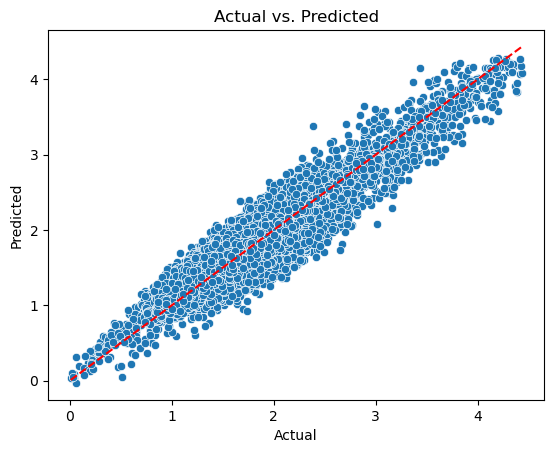

In [18]:
# --- Actual vs Predicted plots ---

# Plot predicted vs actual values on log-transformed scale
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

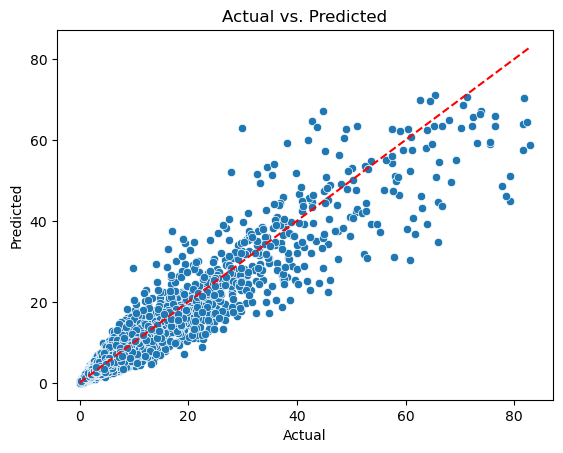

In [19]:
# Plot predicted vs actual values on original scale (inverse transformed)
sns.scatterplot(x=y_test_original, y=y_pred_original)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

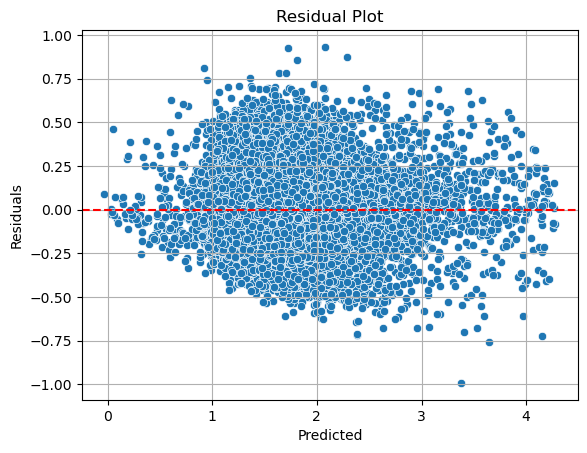

In [20]:
# --- Residual plots to diagnose errors ---

# Residuals on log-transformed scale
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

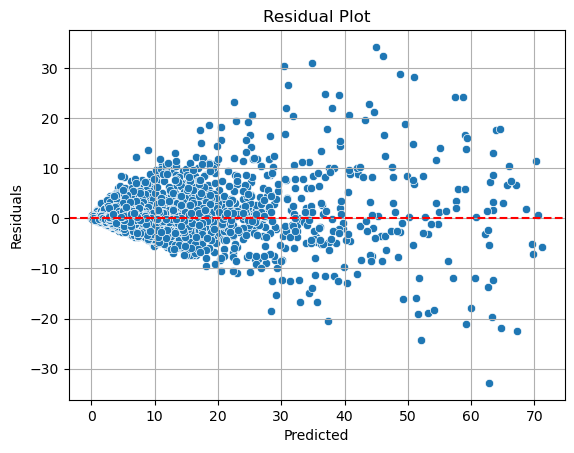

In [21]:
# Residuals on original scale
residuals = y_test_original - y_pred_original

sns.scatterplot(x=y_pred_original, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

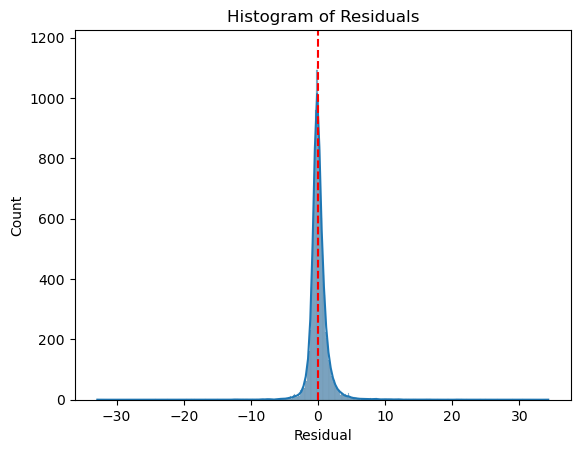

In [22]:
residuals = y_test_original - y_pred_original

sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.show()

In [23]:
# Quantile regression 0.1 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.1',
    iterations=2000,
    learning_rate=0.05,
    depth=9,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.0679181	total: 21.3ms	remaining: 42.7s
500:	learn: 0.0253191	total: 7.45s	remaining: 22.3s
1000:	learn: 0.0240001	total: 14.4s	remaining: 14.4s
1500:	learn: 0.0234481	total: 21.4s	remaining: 7.1s
1999:	learn: 0.0230505	total: 28.1s	remaining: 0us
Train Mean Squared Error: 0.0747, R² Score: 0.6952
Test  Mean Squared Error: 0.0772, R² Score: 0.6935
Original Scale - Test MSE: 6.2899, R²: 0.7793


In [24]:
# Quantile regression 0.5 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.5',
    iterations=2000,
    learning_rate=0.05,
    depth=9,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.1767665	total: 23.9ms	remaining: 47.8s
500:	learn: 0.0647731	total: 8.19s	remaining: 24.5s
1000:	learn: 0.0605017	total: 16.2s	remaining: 16.2s
1500:	learn: 0.0580839	total: 24.1s	remaining: 8.01s
1999:	learn: 0.0563999	total: 32.6s	remaining: 0us
Train Mean Squared Error: 0.0276, R² Score: 0.8873
Test  Mean Squared Error: 0.0341, R² Score: 0.8647
Original Scale - Test MSE: 3.1237, R²: 0.8904


In [25]:
# Quantile regression 0.9 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.9',
    iterations=2000,
    learning_rate=0.05,
    depth=9,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.0985343	total: 22.7ms	remaining: 45.4s
500:	learn: 0.0290623	total: 8.89s	remaining: 26.6s
1000:	learn: 0.0279346	total: 16.5s	remaining: 16.5s
1500:	learn: 0.0275472	total: 23.5s	remaining: 7.81s
1999:	learn: 0.0270739	total: 30.6s	remaining: 0us
Train Mean Squared Error: 0.0882, R² Score: 0.6398
Test  Mean Squared Error: 0.0930, R² Score: 0.6306
Original Scale - Test MSE: 6.4511, R²: 0.7737
